# Electricity predicteur
Transformer based model for Electricity consommation prediction

In [1]:
%pip install matplotlib scikit-learn
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from time import time, strftime, gmtime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from Model_Blocks.Transformer import Transformer
from train_model import *
import Training_elec as Training
from data_prep import *

Note: you may need to restart the kernel to use updated packages.


In [2]:

# Hyper parameters
dataset_path = "data/electricity.csv"
model_path = ''
lr = 1e-3
batch_size = 64
save_dir = "outputs"
nepochs = 10
num_layers = 2
hidden_dim = 64
label_smoothing = 0.0

# Transformer specific
embedding_size = 64
dropout_rate = 0.1
head_size = 64
num_heads = 4
n_encoder_blocks = 3
context_size = 64

col = 'AEP_MW'

In [3]:
# Changing to mps if available

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device :', device)

# Create the directory containing the model, the logs, etc.
dir_name = strftime("%Y-%m-%d_%H-%M-%S", gmtime())
out_dir = os.path.join(save_dir, dir_name)
os.makedirs(out_dir)

path_model = os.path.join(out_dir, "model.pth")
path_model_classif = os.path.join(out_dir, "model_classif.pth")
path_config = os.path.join(out_dir, "config.json")
path_logs = os.path.join(out_dir, "logs.json")

# Save config
with open(path_config, 'w') as f:
    # storing variables is a bit hacky without argparse, just saving a dict manually or empty
    # replicating user style who dumped vars(args)
    config = {
        "dataset_path": dataset_path,
        "lr": lr, 
        "batch_size": batch_size,
        "nepochs": nepochs,
        "hidden_dim": hidden_dim
    }
    json.dump(config, f)
    f.write('\n')

print('Dataset path :', dataset_path)
print('batch_size :', batch_size)

Device : cuda
Dataset path : data/electricity.csv
batch_size : 64


In [4]:
# Import the dataset
df = pd.read_csv(dataset_path)
df = df[[col]]
print(df)

# Normalizing data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_dataset = scaler.fit_transform(df)


# Separating the train and test sets
train_dataset, test_dataset = train_test_split(
    scaled_dataset,
    test_size=0.15,
    shuffle=False
)

train_labels = (train_dataset[1:]-train_dataset[:-1])>0
test_labels = (test_dataset[1:]-test_dataset[:-1])>0
# cast to int
train_labels = train_labels.astype(int)
test_labels = test_labels.astype(int)


# Get training and test size
train_size, input_dim = train_dataset.shape
test_size, _ = test_dataset.shape

train_dataloader = dataset_from_numpy(train_dataset, train_labels, context_size, batch_size)
test_dataloader = dataset_from_numpy(test_dataset, test_labels, context_size, batch_size)

print('train_size :', train_size)
print('test_size :', test_size)
print('n_features :', input_dim)

         AEP_MW
0       13478.0
1       12865.0
2       12577.0
3       12517.0
4       12670.0
...         ...
121268  21089.0
121269  20999.0
121270  20820.0
121271  20415.0
121272  19993.0

[121273 rows x 1 columns]
train_size : 103082
test_size : 18191
n_features : 1


In [5]:
####################
# Training a model #
####################


# Importing a Transformer
model = Transformer(
    input_dim, 
    num_classes=2,
    embedding_size=embedding_size,
    dropout_rate=dropout_rate, 
    head_size=head_size, 
    num_heads=num_heads,
    n_encoder_blocks=n_encoder_blocks,
    max_context_size=context_size
)

# Load weights if specified
if model_path != '':
    model.load_state_dict(torch.load(model_path, weights_only=True))

# Changing to appropriate device
model.to(device)

print(model)
print("Number of Parameters :", sum(p.numel() for p in model.parameters()))

Transformer(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-2): 3 x EncoderBlock(
        (multi_head_attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-3): 4 x Head(
              (Q): Linear(in_features=64, out_features=64, bias=False)
              (K): Linear(in_features=64, out_features=64, bias=False)
              (V): Linear(in_features=64, out_features=16, bias=False)
            )
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=64, out_features=64, bias=True)
        )
        (layer_norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (feed_forward): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): Dropout(p=0.05, inplace=False)
          (2): GELU(approximate='none')
          (3): Linear(in_features=256, out_features=64, bias=True)
        )
        (layer_norm2): LayerNorm(

In [6]:
# Load model weights
model.load_state_dict(torch.load('transformer_model.pth'))
model.to(device)

# Loss functions
criterion_classif = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing)

# Optimizers
optimizer_classif = optim.Adam(model.parameters(), lr=lr)

#Training.train_model(model, train_dataloader, test_dataloader, optimizer=optimizer_classif, criterion=criterion_classif , num_epochs=nepochs, device=device, batch_size=batch_size)

# Save model
path_model = 'transformer_model.pth'
torch.save(model.state_dict(), path_model)

In [18]:
# autoreload module
%load_ext autoreload
%autoreload 2
from trading import trading_test_transformer_elec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ML
Other


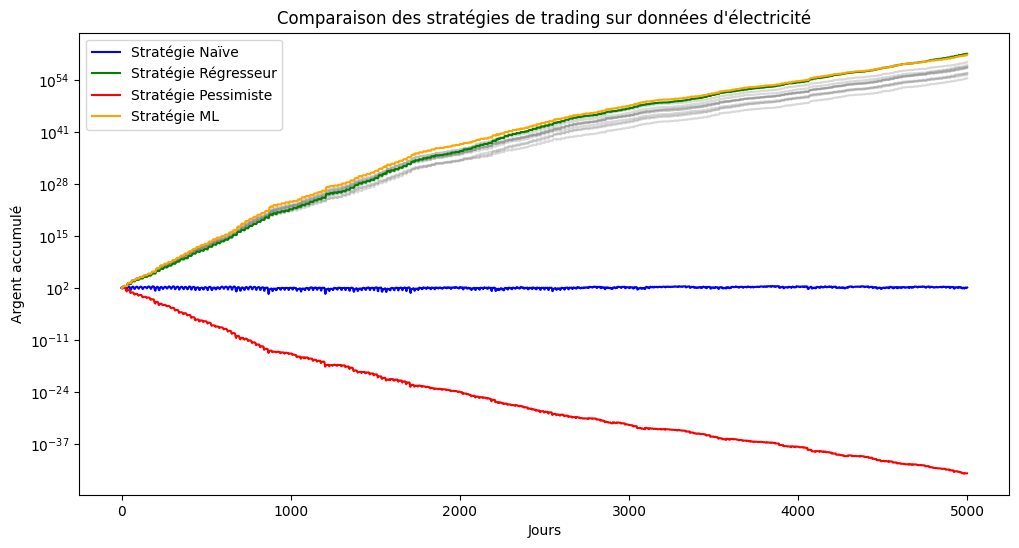

In [22]:
trading_test_transformer_elec(train_dataset,test_dataset[:5000],model_classifier=model,context_size=context_size,value_data = test_dataset[:5000,-1])